In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import re
pd.set_option('mode.chained_assignment', None)
import health_model as hm

In [2]:
def add_clock(df):
    df['hour'] = df['time']/3600
    df['minute'] = (df['time'] - df['hour']*3600) / 60
    df['seconds'] = df['time'] - (df['hour']*3600) - (df['minute'] * 60)
    df['clock'] = pd.to_datetime("2025-06-26") + pd.to_timedelta(df['time'], unit='s')
    df['sim_clock'] = df.clock.apply(lambda x: pd.Timestamp(x).strftime('%H:%M:%S'))
    return(df)

In [3]:
def tidy_oids_to_names(n):
    n = n.replace("/root/Main/Map/","").replace("Level1/","")
    if 'Entrance' in n.split('/')[-1]:
        n = '-'.join(n.replace('1','').replace('EntranceContainer','Main').split('/'))
    else:
        n = n.split('/')[-1]
    return(n)

In [4]:
out_dir = '/project/biocomplexity/dtra/Toxin_Building_2025/chem-poison-godot-data/2025-08-25/'
out_fname = 'output_negvalues-fix_Aug25.json'
out_df = pd.read_json(out_dir+out_fname,lines=True)

In [5]:
pe_df = out_df[out_df.event=='poison_exchange']
pe_df = add_clock(pe_df)
pe_df['obj_name'] = pe_df.oid.apply(lambda x: tidy_oids_to_names(x))

In [6]:
### some pids have two different oids at same clock. e.g., 1926074 has Restroom4 and Restroom5
pe_df = pe_df.drop_duplicates(['pid','clock'],keep='last')
pvt_df = pe_df.pivot(index='clock',columns='pid',values='pid_poison_end')
pvt_df.iloc[0] = 0
pvt_df = pvt_df.ffill()

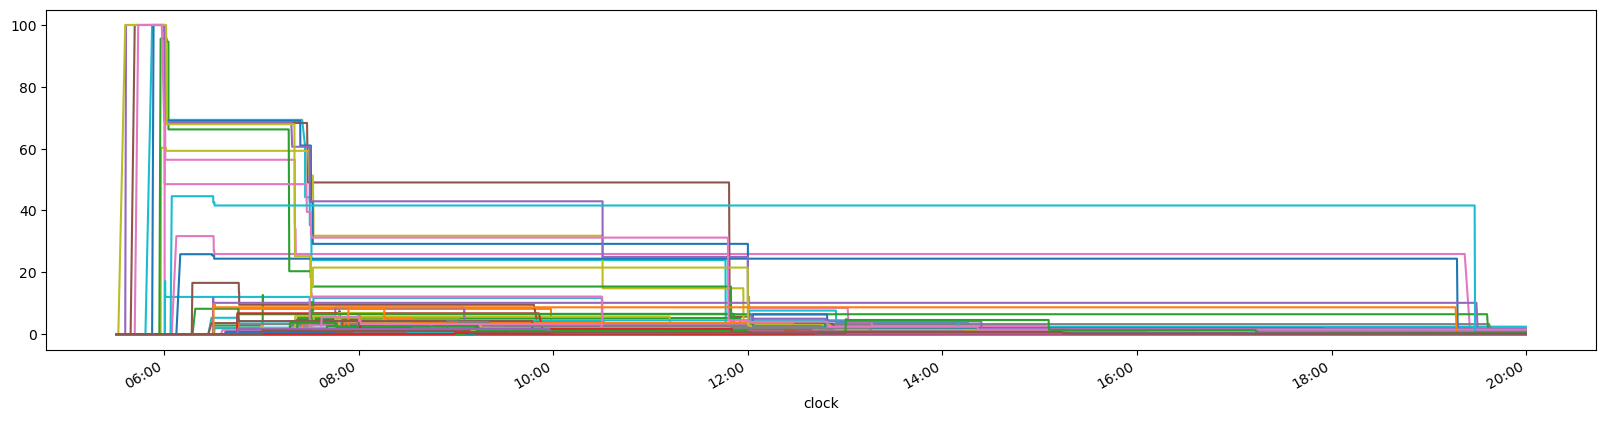

In [7]:
true_pids = (pvt_df.sum().round()!=0).index.values
pvt_df[true_pids].plot(legend=False,figsize=(20,5))
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

In [8]:
true_pe = pe_df[(pe_df.oid_poison_start!=pe_df.oid_poison_end)&(pe_df.pid_poison_start!=pe_df.pid_poison_end)]
true_pe['transfer_to_pid'] = true_pe.apply(lambda x: x['pid_poison_end'] - x['pid_poison_start'],axis=1)
true_pe['transfer_to_obj'] = true_pe.apply(lambda x: x['oid_poison_end'] - x['oid_poison_start'],axis=1)
true_pe = true_pe[(true_pe.transfer_to_pid.round()!=0)&(true_pe.transfer_to_obj.round()!=0)]

true_pe['source'] = true_pe.apply(lambda x: x['pid'] if x['transfer_to_pid']<0 else x['obj_name'],axis=1)
true_pe['target'] = true_pe.apply(lambda x: x['pid'] if x['transfer_to_pid']>=0 else x['obj_name'],axis=1)
true_pe['volume'] = true_pe['transfer_to_pid'].apply(lambda x: np.abs(x))

true_pe = true_pe[['source','target','sim_clock','volume']]

### Absorption analysis

In [9]:
ab_df = out_df[out_df.event=='person_absorption']
ab_df = add_clock(ab_df)

ab_pvt = ab_df.pivot(index='clock',columns='pid',values='absorbed_poison').fillna(0)
poi_pvt = ab_df.pivot(index='clock',columns='pid',values='poison').fillna(0)

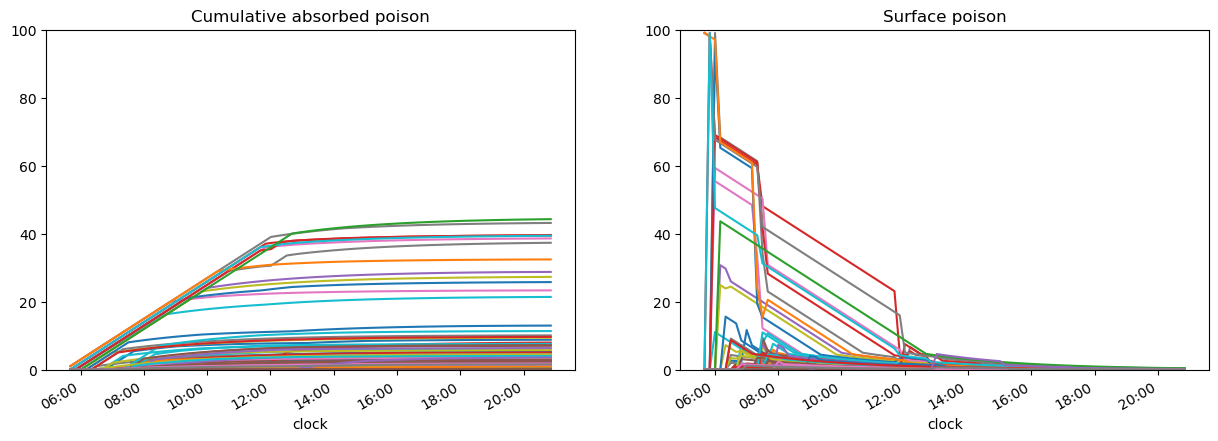

In [10]:
f,axarr = plt.subplots(1,2,figsize=(15,5))
ab_pvt.plot(legend=False,ax=axarr[0])
axarr[0].set_ylim([0,100])
axarr[0].set_title('Cumulative absorbed poison')
axarr[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
poi_pvt.plot(legend=False,ax=axarr[1])
axarr[1].set_ylim([0,100])
axarr[1].set_title('Surface poison')
axarr[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# plt.figure()
# for ill_thresh in [10,20,30]:
#     (ab_pvt>=ill_thresh).sum(axis=1).plot(label="ill at {}".format(ill_thresh))
# plt.legend()

## Health model

### Hill response parameters

* Fitted EC50: 19.19
* Fitted Hill coefficient: 5.00
* Fitted E_max: 1.07

### Time to illness gaussian mixture parameters

<!-- * mu1, sigma1, weight1 = 2.5, 0.5, 0.15
* mu2, sigma2, weight2 = 6.0, 1.5, 0.85
 -->
 
* mu1=2.5, sigma1=0.6, weight1=0.4
* mu2=6.0, sigma2=1.0, weight2=0.6

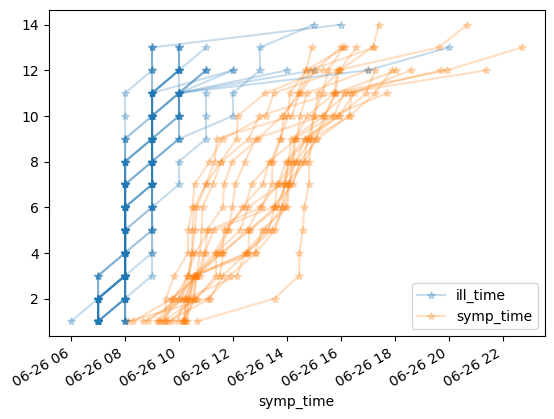

In [15]:
ill_probs = ab_pvt.map(lambda x: hm.hill_response(x))
ill_probs = ill_probs.resample('h').max()

#seed = 12345
hreps = 20
for r in range(hreps):
    seed = None
    if seed is not None:
        np.random.seed(seed)    
    ill_true = ill_probs.apply(lambda x: np.random.random() < x)
    ill_pids = ill_true.columns[ill_true.iloc[-1]]

    ill_times = pd.DataFrame(columns=['pid','ill_time','symp_delay','symp_time'])
    for pid in ill_pids:
        i = ill_true.index.values[np.where(ill_true[pid])[0][0]]
        d = pd.to_timedelta(hm.sample_bimodal()[0], unit='h')
        s = i + d
        ill_times.loc[len(ill_times)] = {'pid':pid,'ill_time':i,'symp_delay':d,'symp_time':s}

    ill_times['ind'] = 1
    ill_times.set_index('ill_time').sort_index()['ind'].cumsum().plot(label='illness',marker='*',alpha=0.25)
    ill_times.set_index('symp_time').sort_index()['ind'].cumsum().plot(label='symptomatic',marker='*',alpha=0.25)
    plt.legend(['ill_time', 'symp_time'])
        
    ax = plt.gca()
    ax.set_prop_cycle(None)